In [1]:
import envs.beachbar 
import envs.gathering 
import envs.doubletarget
import envs.mfg 
import envs.cityrelocation
from utils import *
from importlib import reload
from envs.common_noise_script import *

import utils_bayesian
reload(utils_bayesian)
reload(envs.beachbar)
reload(envs.cityrelocation)
from utils_bayesian import *
from envs.beachbar import *
from envs.cityrelocation import *


/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/envs/beachbar.py:18: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  nb_states: int = eqx.static_field()
/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/envs/beachbar.py:19: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  nb_actions: int = eqx.static_field()
/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/envs/beachbar.py:20: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  H: int = eqx.static_field()
/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/envs/beachbar.py:21: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  eta: float = eqx.static_field()
/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/envs/beachbar.py:22: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  bar_x: int = eqx.static_field()
/home/gregoire/

In [2]:
KF = jax.random.PRNGKey(2026)

In [295]:
city_noise(jax.random.PRNGKey(np.random.randint(54654)), (20,), 64, 0.1)[2]

Array([0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0],      dtype=int32, weak_type=True)

In [296]:
1/64

0.015625

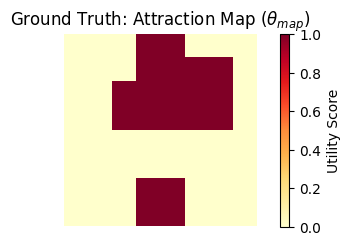

In [297]:
noise = city_noise(jax.random.PRNGKey(np.random.randint(54654)), (1,), 64, 5/NB_STATES)[0]
fig, axes = plt.subplots(1,figsize=(6, 2.5))
true_attraction = noise.reshape(8, 8)
im1 = axes.imshow(true_attraction, cmap='YlOrRd', origin='lower')
axes.set_title("Ground Truth: Attraction Map ($\\theta_{map}$)")
axes.axis('off')
plt.colorbar(im1, ax=axes, label="Utility Score")
# plt.tight_layout()
plt.show()

In [5]:
import jax.random as jr

def city_noise(key, shape, nb_states, eta):
    """
    Returns eps0: 
    - Samples Bernoulli anchors.
    - If an anchor is 1, the entire 2x2 block (SE, SW, NW) is set to 1.
    """
    grid_size = int(np.sqrt(nb_states))
    
    # 1. Sample the "Anchors" (NW corners)
    # Shape: (batch..., nb_states)
    anchors = jr.bernoulli(key, p=eta, shape=(*shape, nb_states))
    
    # 2. Reshape to 2D grid to handle spatial neighbors
    # New shape: (batch..., grid_size, grid_size)
    anchors_2d = anchors.reshape((*shape, grid_size, grid_size))
    
    # 3. Use Max Pooling or a simple Shift-and-OR to expand the 1s
    # We want: block[r,c] = anchor[r,c] | anchor[r-1,c] | anchor[r,c-1] | anchor[r-1,c-1]
    # This ensures that if any "trigger" was hit near a cell, that cell is in the storm.
    
    def shift(x, dr, dc):
        return jnp.roll(x, shift=(dr, dc), axis=(-2, -1))

    # Expand the influence of a 1 to its neighbors (East, South, and South-East)
    # This turns every 1-anchor into the top-left of a 2x2 block
    eps0_2d = (anchors_2d | 
               shift(anchors_2d, 0, 1) |  # Shift Right
               shift(anchors_2d, 1, 0) |  # Shift Down
               shift(anchors_2d, 1, 1))   # Shift Diagonal
    
    # 4. Flatten back to (batch..., nb_states)
    return (1 * eps0_2d).reshape((*shape, nb_states))

# Parameters
H = 20 
NB_STATES = 64
rho0 = jnp.ones(NB_STATES) / NB_STATES

# Initialize City Environment
env_true = CityRelocation(
    generate_common_noise=city_noise,
    rho0=rho0,
    nb_states=NB_STATES,
    H=H, 
    eta = 1/NB_STATES, 
    theta_cong=100, 
    theta_move=1/np.sqrt(NB_STATES)
    )

# def generate_theta(key, batch_size):
#     k1, k2 = jr.split(key, 2)
#     carte = jr.dirichlet(k1, (1/np.sqrt(NB_STATES))*jnp.ones(NB_STATES), (batch_size,))
#     return carte

def generate_theta(key, batch_size, nb_states=NB_STATES):
    grid_size = int(np.sqrt(nb_states))
    k1, k2 = jr.split(key, 2)
    
    alpha       = (1/np.sqrt(nb_states)) * jnp.ones(nb_states)
    raw_carte   = jr.dirichlet(k1, alpha, (batch_size,))
    raw_carte_2d = raw_carte.reshape(batch_size, 1, grid_size, grid_size)
    
    kernel = jnp.ones((1, 1, 2, 2)) / 4.0
    smoothed = jax.lax.conv_general_dilated(
        raw_carte_2d, kernel, window_strides=(1, 1),
        padding='SAME', feature_group_count=1,
        precision=None, dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    
    # Normalize PER SAMPLE, not across the whole batch
    smoothed = smoothed / smoothed.sum(axis=(1, 2, 3), keepdims=True)
    
    return smoothed.reshape(batch_size, nb_states)

key_theta = jr.PRNGKey(43)
true_theta = generate_theta(key_theta, 1)[0]


env_true = env_true.set_theta(true_theta)

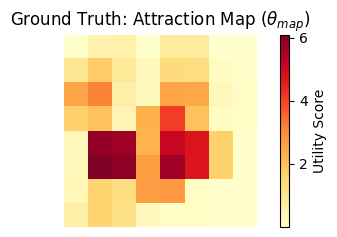

In [6]:
fig, axes = plt.subplots(1,figsize=(6, 2.5))
true_attraction = ((env_true.theta_map.reshape(8, 8))*100)
# true_attraction = ((generate_theta(jax.random.key(np.random.randint(23)), 100)[0].reshape(8, 8))*100)
im1 = axes.imshow(true_attraction, cmap='YlOrRd', origin='lower')
axes.set_title("Ground Truth: Attraction Map ($\\theta_{map}$)")
axes.axis('off')
plt.colorbar(im1, ax=axes, label="Utility Score")
# plt.tight_layout()
plt.show()

In [47]:
reload(envs.cityrelocation)
from envs.cityrelocation import *

In [30]:
reload(utils_bayesian)
from utils_bayesian import *

--- FP Round 1/10 ---


E0424 00:30:10.510691   17744 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.85 = f32[1024,128]{1,0} fusion(concatenate.26, concatenate.25, concatenate.22, concatenate.21, get-tuple-element.794), kind=kCustom, calls=gemm_fusion_dot.85_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 00:30:10.511284   17744 xtile_compiler.cc:401] Computation: gemm_fusion_dot.85_computation.clone {
  parameter_0.21 = f32[128,256]{1,0} parameter(0)
  parameter_1.21 = f32[128,256]{1,0} parameter(1)
  parameter_2 = f32[128,256]{1,0} parameter(2)
  parameter_3 = f32[128,256]{1,0} parameter(3)
  concatenate.91 = f32[128,1024]{1,0} concaten

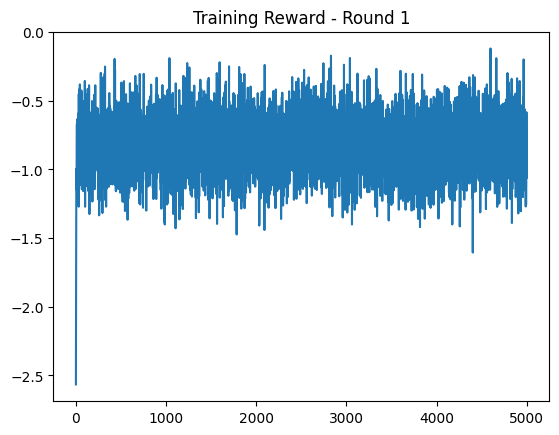

E0424 00:43:53.456425   17750 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.35 = f32[128,6400]{1,0} fusion(constant.860, bitcast.2625), kind=kCustom, calls=gemm_fusion_dot.35_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 00:43:53.456975   17750 xtile_compiler.cc:401] Computation: gemm_fusion_dot.35_computation.clone {
  parameter_0.21 = f32[128,129]{1,0} parameter(0)
  parameter_1.21 = f32[129,6400]{0,1} parameter(1)
  ROOT dot.118 = f32[128,6400]{1,0} dot(parameter_0.21, parameter_1.21), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0424 00:43:54.190164   17741 xtile_com

   Nash Gap: 1.812576
--- FP Round 2/10 ---


E0424 00:44:03.972390   17738 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.74 = f32[128,64,2]{1,2,0} fusion(bitcast.2766, bitcast.2767), kind=kCustom, calls=gemm_fusion_dot.74_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["1","64","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 00:44:03.972935   17738 xtile_compiler.cc:401] Computation: gemm_fusion_dot.74_computation.clone {
  parameter_1.49 = f32[128,320,64]{2,1,0} parameter(1)
  constant_1752 = f32[] constant(0.25)
  broadcast.1447 = f32[128,320,64]{2,1,0} broadcast(constant_1752), dimensions={}
  multiply.52 = f32[128,320,64]{2,1,0} multiply(parameter_1.49, broadcast.1447)
  parameter_0.49 = f32[128,2,320]{2,1,0

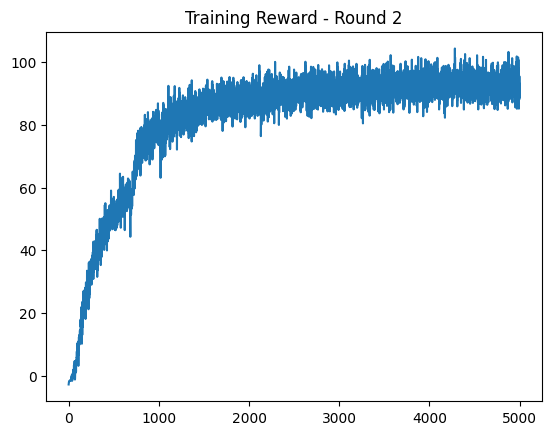

E0424 00:58:11.837790   17737 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.23 = f32[100,64,2]{1,2,0} fusion(bitcast.2338, bitcast.2339), kind=kCustom, calls=gemm_fusion_dot.23_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["1","64","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 00:58:11.838379   17737 xtile_compiler.cc:401] Computation: gemm_fusion_dot.23_computation.clone {
  parameter_1.7 = f32[100,320,64]{2,1,0} parameter(1)
  constant_1859 = f32[] constant(0.25)
  broadcast.1443 = f32[100,320,64]{2,1,0} broadcast(constant_1859), dimensions={}
  multiply.36 = f32[100,320,64]{2,1,0} multiply(parameter_1.7, broadcast.1443)
  parameter_0.7 = f32[100,2,320]{2,1,0} p

   Nash Gap: 95.863808
--- FP Round 3/10 ---


E0424 00:58:23.782164   17743 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.74 = f32[128,64,3]{1,2,0} fusion(bitcast.2766, bitcast.2767), kind=kCustom, calls=gemm_fusion_dot.74_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["1","64","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 00:58:23.782241   17743 xtile_compiler.cc:401] Computation: gemm_fusion_dot.74_computation.clone {
  parameter_1.49 = f32[128,320,64]{2,1,0} parameter(1)
  constant_1752 = f32[] constant(0.25)
  broadcast.1447 = f32[128,320,64]{2,1,0} broadcast(constant_1752), dimensions={}
  multiply.52 = f32[128,320,64]{2,1,0} multiply(parameter_1.49, broadcast.1447)
  parameter_0.49 = f32[128,3,320]{2,1,0

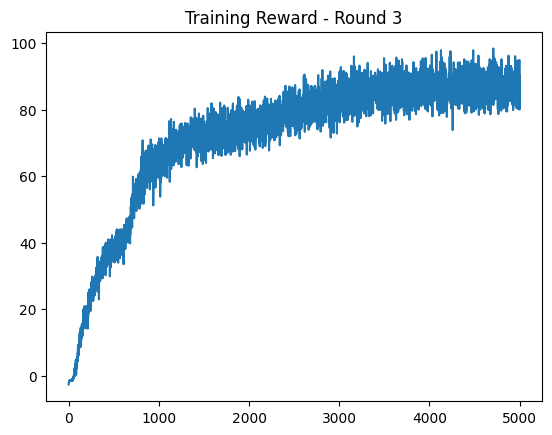

E0424 01:14:08.656870   17755 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.3 = f32[384,6400]{1,0} fusion(constant.1786, bitcast.2413), kind=kCustom, calls=gemm_fusion_dot.3_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 01:14:08.657358   17755 xtile_compiler.cc:401] Computation: gemm_fusion_dot.3_computation.clone {
  parameter_0.8 = f32[384,129]{1,0} parameter(0)
  parameter_1.8 = f32[129,6400]{0,1} parameter(1)
  ROOT dot.78 = f32[384,6400]{1,0} dot(parameter_0.8, parameter_1.8), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0424 01:14:08.986627   17752 xtile_compiler.c

   Nash Gap: 102.418716
--- FP Round 4/10 ---


E0424 01:14:21.050637   17740 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.64 = f32[4,128,8192]{2,1,0} fusion(constant.847..sunk.1, bitcast.2746), kind=kCustom, calls=gemm_fusion_dot.64_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["1","128","16"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 01:14:21.051212   17740 xtile_compiler.cc:401] Computation: gemm_fusion_dot.64_computation.clone {
  parameter_0.42 = f32[4,128,129]{2,1,0} parameter(0)
  parameter_1.42 = f32[4,129,8192]{2,1,0} parameter(1)
  ROOT dot.132 = f32[4,128,8192]{2,1,0} dot(parameter_0.42, parameter_1.42), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backe

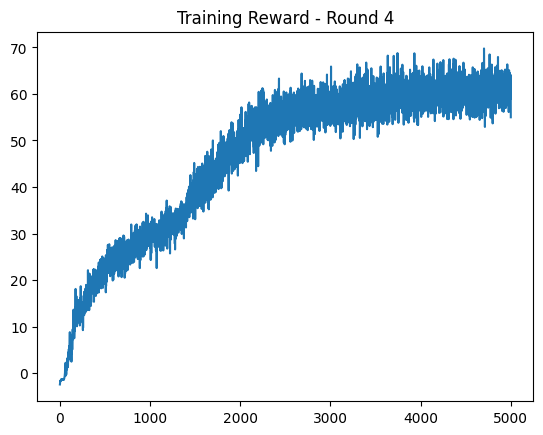

E0424 01:31:42.205289   17745 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.3 = f32[512,6400]{1,0} fusion(constant.1786, bitcast.2413), kind=kCustom, calls=gemm_fusion_dot.3_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 01:31:42.205416   17745 xtile_compiler.cc:401] Computation: gemm_fusion_dot.3_computation.clone {
  parameter_0.8 = f32[512,129]{1,0} parameter(0)
  parameter_1.8 = f32[129,6400]{0,1} parameter(1)
  ROOT dot.78 = f32[512,6400]{1,0} dot(parameter_0.8, parameter_1.8), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["32"]}
}
E0424 01:31:42.370070   17755 xtile_compiler.

   Nash Gap: 86.449089
--- FP Round 5/10 ---


E0424 01:31:54.682249   17743 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.64 = f32[5,128,8192]{2,1,0} fusion(constant.847..sunk.1, bitcast.2746), kind=kCustom, calls=gemm_fusion_dot.64_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 01:31:54.683449   17743 xtile_compiler.cc:401] Computation: gemm_fusion_dot.64_computation.clone {
  parameter_0.42 = f32[5,128,129]{2,1,0} parameter(0)
  parameter_1.42 = f32[5,129,8192]{2,1,0} parameter(1)
  ROOT dot.132 = f32[5,128,8192]{2,1,0} dot(parameter_0.42, parameter_1.42), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backe

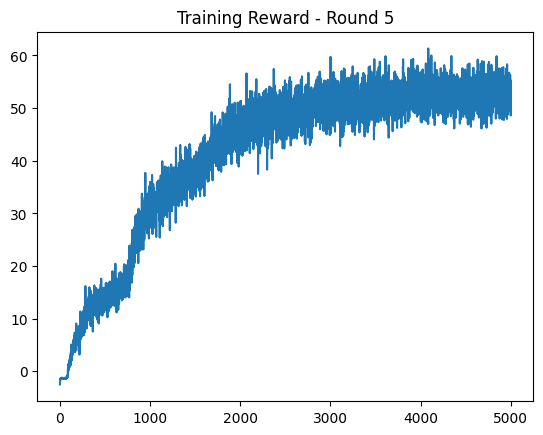

E0424 01:50:46.217495   17749 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.13 = f32[5,128,6400]{2,1,0} fusion(constant.468, bitcast.2318), kind=kCustom, calls=gemm_fusion_dot.13_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 01:50:46.217659   17749 xtile_compiler.cc:401] Computation: gemm_fusion_dot.13_computation.clone {
  parameter_0 = f32[5,128,129]{2,1,0} parameter(0)
  parameter_1 = f32[5,129,6400]{2,1,0} parameter(1)
  ROOT dot.70 = f32[5,128,6400]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backend_config={"sizes":[

   Nash Gap: 77.286530
--- FP Round 6/10 ---


E0424 01:50:59.327350   17751 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.64 = f32[6,128,8192]{2,1,0} fusion(constant.847..sunk.1, bitcast.2746), kind=kCustom, calls=gemm_fusion_dot.64_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 01:50:59.327486   17751 xtile_compiler.cc:401] Computation: gemm_fusion_dot.64_computation.clone {
  parameter_0.42 = f32[6,128,129]{2,1,0} parameter(0)
  parameter_1.42 = f32[6,129,8192]{2,1,0} parameter(1)
  ROOT dot.132 = f32[6,128,8192]{2,1,0} dot(parameter_0.42, parameter_1.42), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backe

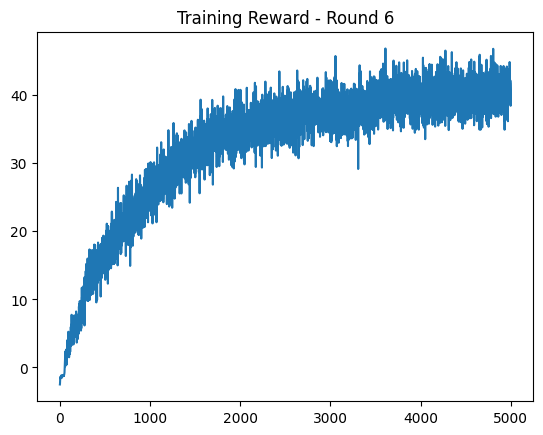

E0424 02:11:00.133480   17735 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.23 = f32[100,64,6]{1,2,0} fusion(bitcast.2338, bitcast.2339), kind=kCustom, calls=gemm_fusion_dot.23_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["1","64","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 02:11:00.133628   17735 xtile_compiler.cc:401] Computation: gemm_fusion_dot.23_computation.clone {
  parameter_1.7 = f32[100,320,64]{2,1,0} parameter(1)
  constant_1859 = f32[] constant(0.25)
  broadcast.1443 = f32[100,320,64]{2,1,0} broadcast(constant_1859), dimensions={}
  multiply.36 = f32[100,320,64]{2,1,0} multiply(parameter_1.7, broadcast.1443)
  parameter_0.7 = f32[100,6,320]{2,1,0} p

   Nash Gap: 61.033863
--- FP Round 7/10 ---


E0424 02:11:14.764213   17741 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.74 = f32[128,64,7]{1,2,0} fusion(bitcast.2766, bitcast.2767), kind=kCustom, calls=gemm_fusion_dot.74_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["1","64","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 02:11:14.764708   17741 xtile_compiler.cc:401] Computation: gemm_fusion_dot.74_computation.clone {
  parameter_1.49 = f32[128,320,64]{2,1,0} parameter(1)
  constant_1752 = f32[] constant(0.25)
  broadcast.1447 = f32[128,320,64]{2,1,0} broadcast(constant_1752), dimensions={}
  multiply.52 = f32[128,320,64]{2,1,0} multiply(parameter_1.49, broadcast.1447)
  parameter_0.49 = f32[128,7,320]{2,1,0

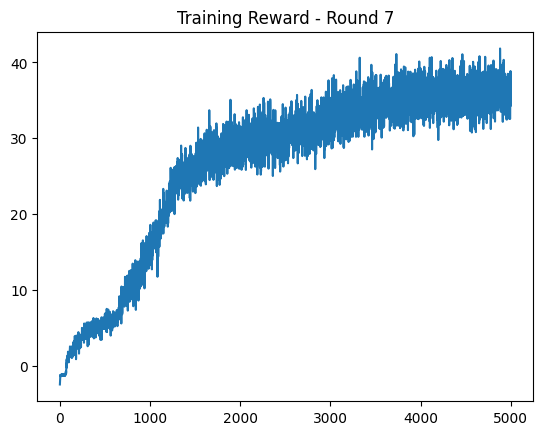

E0424 02:32:28.873939   17744 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.13 = f32[7,128,6400]{2,1,0} fusion(constant.468, bitcast.2318), kind=kCustom, calls=gemm_fusion_dot.13_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 02:32:28.874096   17744 xtile_compiler.cc:401] Computation: gemm_fusion_dot.13_computation.clone {
  parameter_0 = f32[7,128,129]{2,1,0} parameter(0)
  parameter_1 = f32[7,129,6400]{2,1,0} parameter(1)
  ROOT dot.70 = f32[7,128,6400]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backend_config={"sizes":[

   Nash Gap: 52.919292
--- FP Round 8/10 ---


E0424 02:32:43.380869   17734 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.64 = f32[8,128,8192]{2,1,0} fusion(constant.847..sunk.1, bitcast.2746), kind=kCustom, calls=gemm_fusion_dot.64_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["1","128","16"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 02:32:43.381076   17734 xtile_compiler.cc:401] Computation: gemm_fusion_dot.64_computation.clone {
  parameter_0.42 = f32[8,128,129]{2,1,0} parameter(0)
  parameter_1.42 = f32[8,129,8192]{2,1,0} parameter(1)
  ROOT dot.132 = f32[8,128,8192]{2,1,0} dot(parameter_0.42, parameter_1.42), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backe

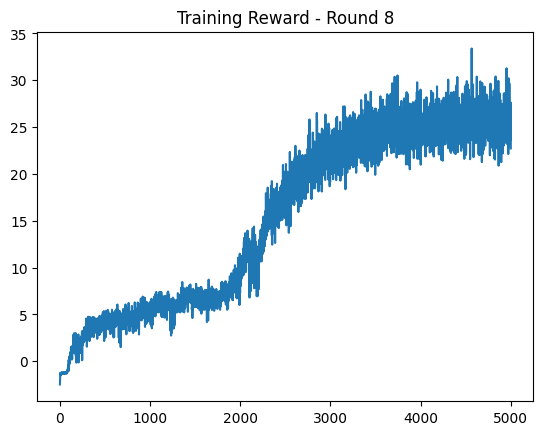

E0424 02:55:08.348633   17746 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.3 = f32[1024,6400]{1,0} fusion(constant.1786, bitcast.2413), kind=kCustom, calls=gemm_fusion_dot.3_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 02:55:08.348802   17746 xtile_compiler.cc:401] Computation: gemm_fusion_dot.3_computation.clone {
  parameter_0.8 = f32[1024,129]{1,0} parameter(0)
  parameter_1.8 = f32[129,6400]{0,1} parameter(1)
  ROOT dot.78 = f32[1024,6400]{1,0} dot(parameter_0.8, parameter_1.8), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0424 02:55:08.702528   17738 xtile_compile

   Nash Gap: 38.379616
--- FP Round 9/10 ---


E0424 02:55:23.467205   17736 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.64 = f32[9,128,8192]{2,1,0} fusion(constant.847..sunk.1, bitcast.2746), kind=kCustom, calls=gemm_fusion_dot.64_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["1","128","16"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 02:55:23.467373   17736 xtile_compiler.cc:401] Computation: gemm_fusion_dot.64_computation.clone {
  parameter_0.42 = f32[9,128,129]{2,1,0} parameter(0)
  parameter_1.42 = f32[9,129,8192]{2,1,0} parameter(1)
  ROOT dot.132 = f32[9,128,8192]{2,1,0} dot(parameter_0.42, parameter_1.42), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backe

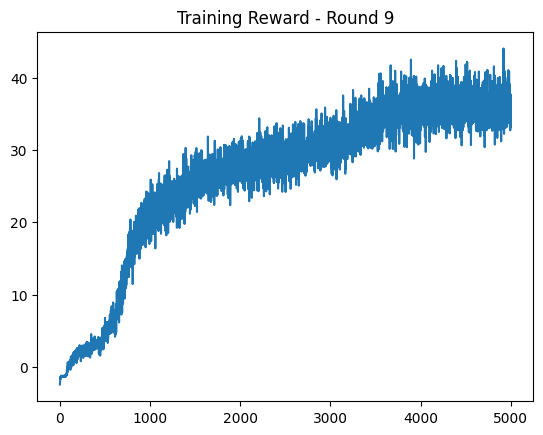

E0424 03:19:06.716038   17735 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.3 = f32[1152,6400]{1,0} fusion(constant.1786, bitcast.2413), kind=kCustom, calls=gemm_fusion_dot.3_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 03:19:06.716415   17735 xtile_compiler.cc:401] Computation: gemm_fusion_dot.3_computation.clone {
  parameter_0.8 = f32[1152,129]{1,0} parameter(0)
  parameter_1.8 = f32[129,6400]{0,1} parameter(1)
  ROOT dot.78 = f32[1152,6400]{1,0} dot(parameter_0.8, parameter_1.8), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0424 03:19:06.823479   17740 xtile_compile

   Nash Gap: 45.642159
--- FP Round 10/10 ---


E0424 03:19:21.568946   17751 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.74 = f32[128,64,10]{1,2,0} fusion(bitcast.2766, bitcast.2767), kind=kCustom, calls=gemm_fusion_dot.74_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 03:19:21.569065   17751 xtile_compiler.cc:401] Computation: gemm_fusion_dot.74_computation.clone {
  parameter_1.49 = f32[128,320,64]{2,1,0} parameter(1)
  constant_1752 = f32[] constant(0.25)
  broadcast.1447 = f32[128,320,64]{2,1,0} broadcast(constant_1752), dimensions={}
  multiply.52 = f32[128,320,64]{2,1,0} multiply(parameter_1.49, broadcast.1447)
  parameter_0.49 = f32[128,10,320]{2,1

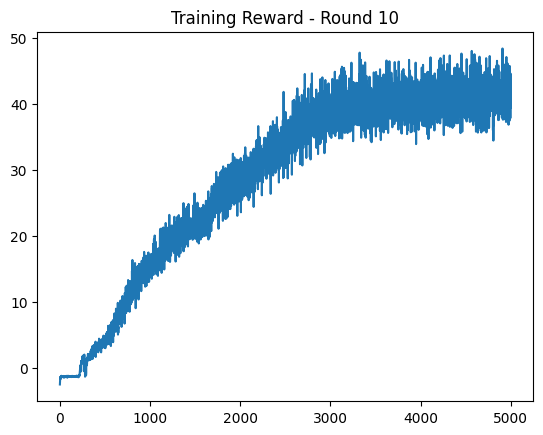

E0424 03:44:17.960410   17755 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.13 = f32[10,128,6400]{2,1,0} fusion(constant.468, bitcast.2318), kind=kCustom, calls=gemm_fusion_dot.13_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 03:44:17.960948   17755 xtile_compiler.cc:401] Computation: gemm_fusion_dot.13_computation.clone {
  parameter_0 = f32[10,128,129]{2,1,0} parameter(0)
  parameter_1 = f32[10,129,6400]{2,1,0} parameter(1)
  ROOT dot.70 = f32[10,128,6400]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backend_config={"sizes

   Nash Gap: 48.506069


In [7]:
pi_bays  = BayesianPolicyCityCNN(env_true, key=jax.random.PRNGKey(0), film_hidden=128)
fictitious_ensemble_bays,nash_gaps_bays = run_fictitious_play_recursive_bayesian(env_true, 10, pi_bays,rho0,
                                                                       generate_theta,
                                                                       n_train_iters=5000,
                                                                       batch_size_train=128,size_mc=1000, #64
                                                                       nb_batch_mc=10,lr = 1e-3,
                                                                       plot_report=True, 
                                                                       model_type=BayesianPolicyCityCNN
                                                                       )

In [8]:
# After training, check actual reward
pi_test = lambda t, x, r: fictitious_ensemble_bays[-1](t, x, r, true_theta)
eps0_test = env_true.common_noise(jax.random.PRNGKey(0), (env_true.H,))
rho_test = generate_mean_field_scan(env_true, rho0, pi_test, eps0_test)
reward_test = compute_total_reward(env_true, rho_test, pi_test, rho_test)
print(f"Actual reward: {reward_test:.2f}")  # should be ~100

Actual reward: -400.79


In [9]:
# Max possible reward (best response to true_theta with no congestion)
max_reward = env_true.theta_map.max() * env_true.nb_states * env_true.H
print(f"Max possible reward (approx): {max_reward:.2f}")

# Stay policy reward
pi_stay = lambda t, x, r: jnp.array([1., 0., 0., 0., 0.])  # always Stay
eps0_test = env_true.common_noise(jax.random.PRNGKey(0), (env_true.H,))
rho_stay = generate_mean_field_scan(env_true, rho0, pi_stay, eps0_test)
reward_stay = compute_total_reward(env_true, rho_stay, pi_stay, rho_stay)
print(f"Stay policy reward: {reward_stay:.2f}")

# After K rounds of fictitious play
pi_trained = lambda t, x, r: fictitious_ensemble_bays[-1](t, x, r, true_theta)
rho_trained = generate_mean_field_scan(env_true, rho0, pi_trained, eps0_test)
reward_trained = compute_total_reward(env_true, rho_trained, pi_trained, rho_trained)
print(f"Trained Bayesian policy reward: {reward_trained:.2f}")

Max possible reward (approx): 78.13
Stay policy reward: -6.10
Trained Bayesian policy reward: -400.79


In [6]:
reload(utils_bayesian)
from utils_bayesian import *

/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/utils_bayesian.py:150: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  depth: int = eqx.static_field()
/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/utils_bayesian.py:151: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  nb_states: int = eqx.static_field()
/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/utils_bayesian.py:152: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  vanilla: bool = eqx.static_field()
/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/utils_bayesian.py:153: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  activation: callable = eqx.static_field()


In [10]:
pi_expert_bays, l_expert = learn_fictitious_policy_bayesian(env_true, rho0, fictitious_ensemble_bays,generate_theta, 1000, 128, 1e-2, model_type= BayesianPolicyCityCNN) #100_000

E0424 08:04:41.087637   17739 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.35 = f32[11,128,163840]{2,1,0} fusion(get-tuple-element.889, bitcast.2958), kind=kCustom, calls=gemm_fusion_dot.35_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0424 08:04:41.087826   17739 xtile_compiler.cc:401] Computation: gemm_fusion_dot.35_computation.clone {
  parameter_0.37 = f32[11,128,129]{2,1,0} parameter(0)
  parameter_1.37 = f32[11,129,163840]{2,1,0} parameter(1)
  ROOT dot.126 = f32[11,128,163840]{2,1,0} dot(parameter_0.37, parameter_1.37), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims

JaxRuntimeError: INTERNAL: Failed to autotune: 2 out of 43 instructions. See logs for details.
Autotuning failed for HLO: %gemm_fusion_dot.35 = f32[11,128,163840]{2,1,0} fusion(%get-tuple-element.889, %bitcast.2958), kind=kCustom, calls=%gemm_fusion_dot.35_computation, metadata={op_name="jit(scan)/while/body/closed_call/jvp(vmap(vmap(vmap(vmap(eqx.nn.Linear)))))/dot_general" stack_frame_id=939}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_gemm"},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"} with error: NOT_FOUND: No valid config found! Failures: 10
EXECUTION FAILED: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 880.00MiB. [tf-allocator-allocation-error='']
EXECUTION FAILED: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 880.00MiB. [tf-allocator-allocation-error='']
EXECUTION FAILED: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 880.00Mi

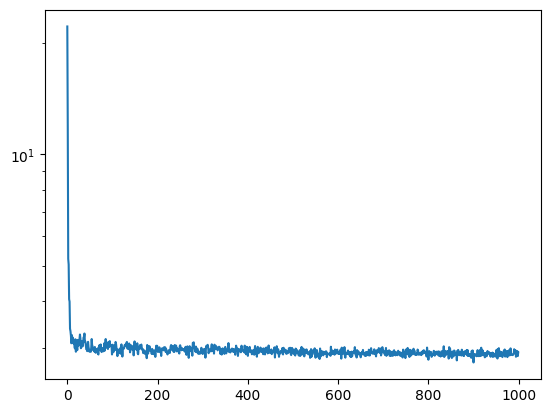

In [ ]:
plt.plot(l_expert)
plt.yscale('log')

In [ ]:
env_true.theta_dim

16

In [8]:
def plot_city_evolution(rho_path, theta, title="City Population Evolution"):
    H_total = rho_path.shape[0]
    nb_states = rho_path.shape[1]
    x_dim = int(jnp.sqrt(nb_states))
    print(nb_states, x_dim)
    
    l = int(np.sqrt(H_total))
    fig, axes = plt.subplots(l+1, l, figsize=(5, 6))
    fig.suptitle(title, fontsize=16)

    for i in range(H_total):
        grid_rho = rho_path[i].reshape(x_dim, x_dim)
        im = axes[i//l, i%l].imshow(grid_rho, cmap='YlOrRd', origin='lower')
        axes[i//l, i%l].set_title(f"t = {i}")
        axes[i//l, i%l].axis('off')
        
    plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
    plt.show()
    
    fig, axes = plt.subplots(1,figsize=(6, 2.5))
    true_attraction = theta.reshape(x_dim, x_dim)
    im1 = axes.imshow(true_attraction, cmap='YlOrRd', origin='lower')
    axes.set_title("Ground Truth: Attraction Map ($\\theta_{map}$)")
    axes.axis('off')
    plt.colorbar(im1, ax=axes, label="Utility Score")
    plt.tight_layout()

In [9]:
indices_I = jnp.arange(H-1, 0, -1)[::-1]

In [10]:
indices_I

Array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19], dtype=int32)

In [ ]:

model_flow_city = ConditionalMAF(
    event_dim      = len(indices_I) * NB_STATES,  # 304
    context_dim    = NB_STATES,             # 16
    hidden_dim     = 512,                   # 256 → 512
    num_layers     = 8,                     # 5 → 8
    nb_states      = NB_STATES,
    theta_embed_dim = 128,                  # 64 → 128 (context_dim doubled)
    key            = jax.random.PRNGKey(0),
    use_simplex=True,
)

model_flow_city, loss_flow = train_nle_online(
    env_true, model_flow_city, rho0, generate_theta, pi_expert_bays,
    n_steps    = 25_000,
    indices_I=indices_I,
    lr         = 1e-5,
    batch_size = 256,
    key        = jax.random.PRNGKey(1)
)

/tmp/ipykernel_94885/3308384744.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  model_flow_city = ConditionalMAF(
E0422 20:25:43.446459   95067 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.54 = f32[4,256,512]{2,1,0} fusion(bitcast.3, bitcast.2), kind=kCustom, calls=gemm_fusion_dot_general.54_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0422 20:25:43.446568   95067 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.54_computation.clone {
  parameter_0.33 = f32[256,4,304]{2,1,0} parameter(0)
  parameter_1.33 = f32[4,30

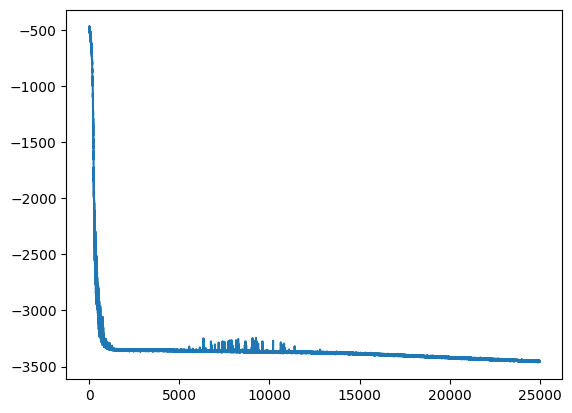

In [22]:
plt.plot(loss_flow)

64 8


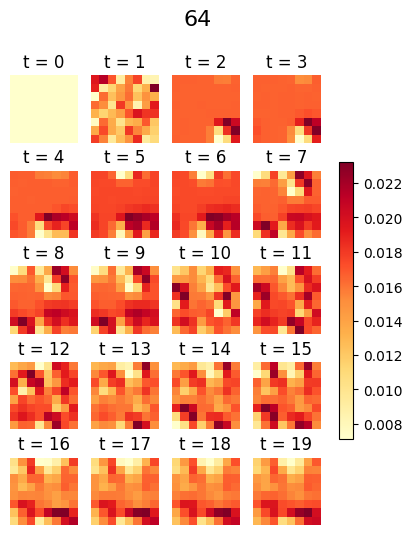

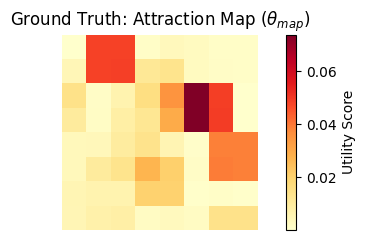

In [29]:
eps0 = env_true.common_noise(KF, (env_true.H,))
pi_test  = lambda t, x, r: pi_expert_bays(t, x, r, env_true.theta_map)
rho = generate_mean_field_scan(env_true, rho0, pi_test, eps0)

plot_city_evolution(rho,env_true.theta_map, NB_STATES)


In [15]:
p_b = lambda t, x, r: pi_bays(t, x, r, env_true.theta_map)
rho_r = generate_mean_field_scan(env_true, rho0,p_b, eps0 )
compute_total_reward(env_true, rho_r, p_b, rho)

Array(28.51901, dtype=float32)

In [12]:
compute_total_reward(env_true, rho, pi_test, rho)

Array(30.287268, dtype=float32)

In [30]:
NB_STATES*(0.06*2), NB_STATES*(0.02*2)

(7.68, 2.56)

E0423 21:18:22.212302    6960 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.2 = f32[64,64]{1,0} fusion(concatenate.0, get-tuple-element.45), kind=kCustom, calls=gemm_fusion_dot.2_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0423 21:18:22.212442    6960 xtile_compiler.cc:401] Computation: gemm_fusion_dot.2_computation.clone {
  parameter_0 = f32[64,129]{1,0} parameter(0)
  parameter_1 = f32[64,129]{1,0} parameter(1)
  ROOT dot.6 = f32[64,64]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={1}, backend_config={"sizes":["64"]}
}
E0423 21:18:22.240759    6967 xtile_compiler.cc:399] Fusi

Max diff between trajectories: 0.007795224
64 8


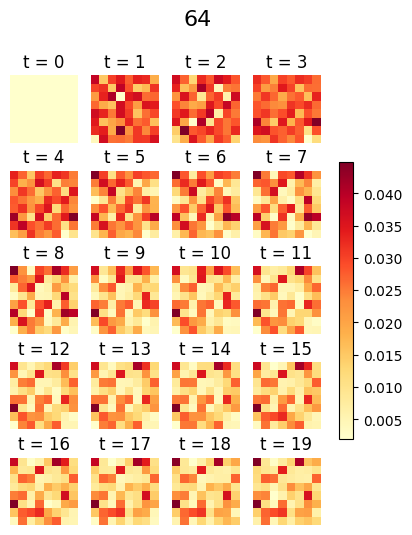

64 8


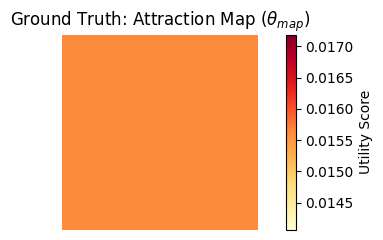

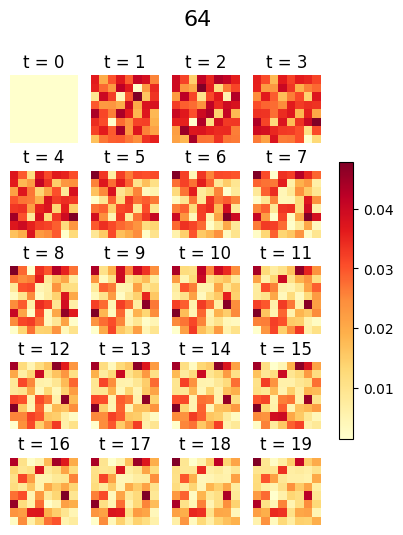

64 8


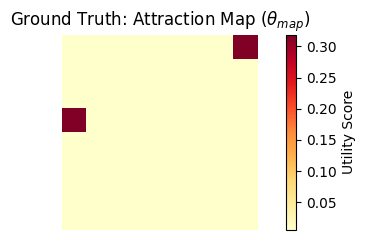

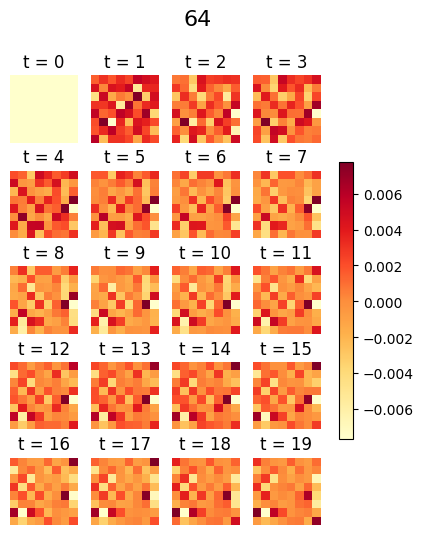

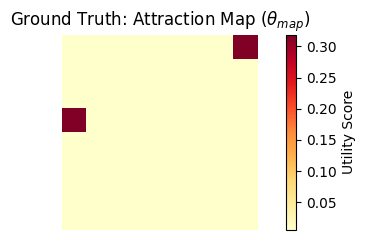

In [18]:
# Do the ACTUAL environment dynamics differ between thetas?
peaked_arr = jnp.ones(NB_STATES)
peaked_arr = peaked_arr.at[-1].set(5)
peaked_arr = peaked_arr.at[NB_STATES//2].set(5)
theta_peaked  = jax.nn.softmax(peaked_arr)
theta_uniform = jnp.ones(NB_STATES) / NB_STATES

key = jax.random.PRNGKey(0)
eps0 = env_true.common_noise(key, (env_true.H,))

pi_peaked  = lambda t, x, r: pi_expert_bays(t, x, r, theta_peaked)
pi_uniform = lambda t, x, r: pi_expert_bays(t, x, r, theta_uniform)

rho_peaked  = generate_mean_field_scan(env_true,  rho0, pi_peaked,  eps0)
rho_uniform = generate_mean_field_scan(env_true, rho0, pi_uniform, eps0)

print("Max diff between trajectories:", jnp.max(jnp.abs(rho_peaked - rho_uniform)))

plot_city_evolution(rho_uniform,  theta_uniform, NB_STATES)
plot_city_evolution(rho_peaked, theta_peaked, NB_STATES)
plot_city_evolution(rho_peaked - rho_uniform, theta_peaked, NB_STATES)

Max diff between trajectories: 0.037968397
64 8


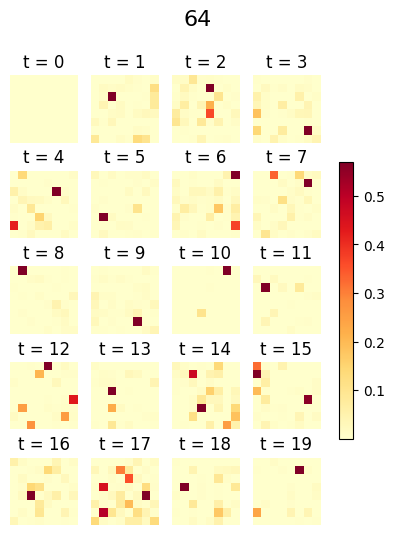

64 8


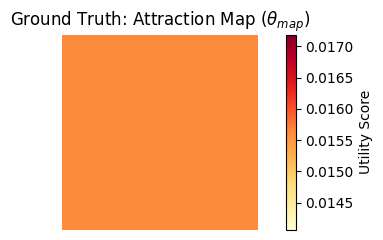

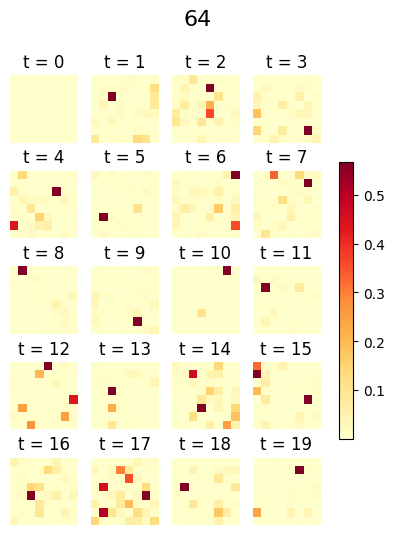

64 8


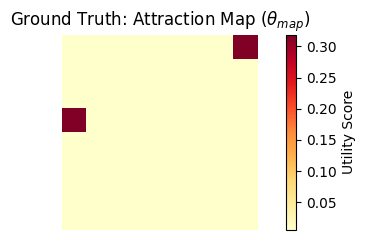

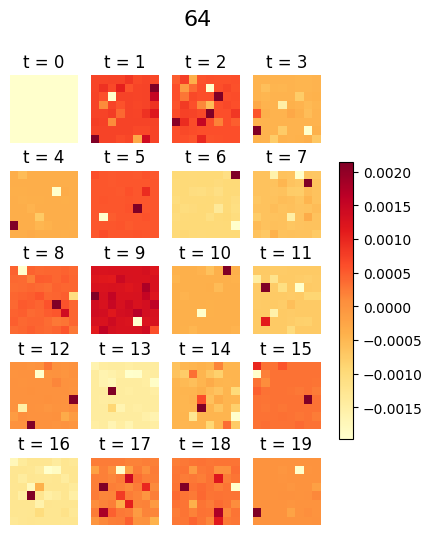

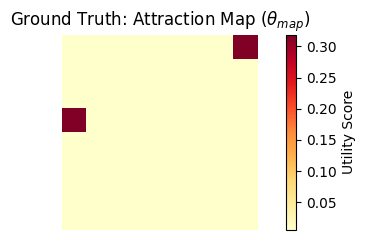

In [24]:
key = jax.random.PRNGKey(99)

# Two very different thetas
peaked_arr = jnp.ones(NB_STATES)
peaked_arr = peaked_arr.at[-1].set(5)
peaked_arr = peaked_arr.at[NB_STATES//2].set(5)
theta_peaked  = jax.nn.softmax(peaked_arr)
theta_uniform = jnp.ones(NB_STATES) / NB_STATES
# Sample from each
r_uniform = model_flow_city.sample(theta_uniform, rho0, key, num_samples=5)
r_peaked  = model_flow_city.sample(theta_peaked,  rho0, key, num_samples=5)

print("Max diff between trajectories:", jnp.max(jnp.abs(rho_peaked - rho_uniform)))
# They should look DIFFERENT if the flow has learned the conditioning
plot_city_evolution(r_uniform[0].reshape(H, NB_STATES), theta_uniform, NB_STATES)
plot_city_evolution(r_peaked[0].reshape(H, NB_STATES),  theta_peaked, NB_STATES)
plot_city_evolution(r_peaked[0].reshape(H, NB_STATES) - r_uniform[0].reshape(H, NB_STATES),  theta_peaked, NB_STATES)

In [11]:
reload(envs.cityrelocation)
from envs.cityrelocation import *

/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/envs/cityrelocation.py:16: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  nb_states: int = eqx.static_field()
/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/envs/cityrelocation.py:17: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  nb_actions: int = eqx.static_field()
/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/envs/cityrelocation.py:18: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  grid_size: int = eqx.static_field()
/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/envs/cityrelocation.py:19: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  H: int = eqx.static_field()
/home/gregoire/PhD_Projects/BayesianMFG/JaxCodes/envs/cityrelocation.py:20: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  theta_dim: in

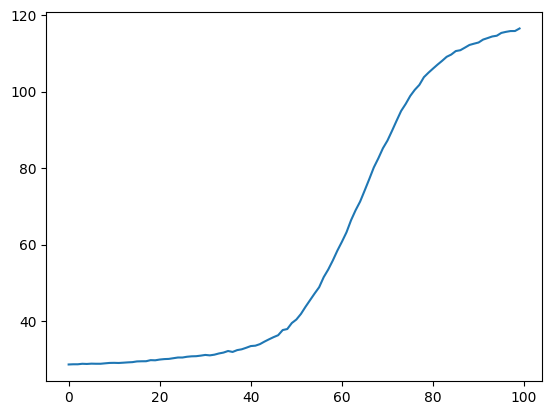

   Nash Gap: 88.120689


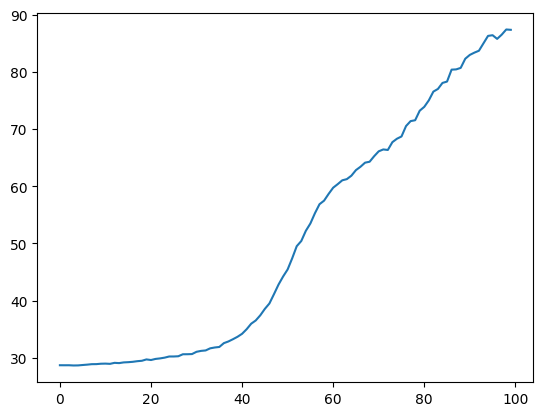

   Nash Gap: 19.520414


In [28]:
# Initialize a uniform policy pi(a|s)
# Size: (H, NB_STATES, NB_ACTIONS)
pi_init  = PolicyNN(env_true, key=jax.random.PRNGKey(0))

# fictitious_ensemble,nash_gaps = run_fictitious_play_recursive(env_true, 15, pi,rho0,
#                                                                        n_train_iters=10000,
#                                                                        batch_size_train=1024,size_mc=1000,
#                                                                        nb_batch_mc=10,lr = 5e-4,
#                                                                        plot_report=True,
#                                                                        key=jax.random.PRNGKey(10))

# Run Fictitious Play to find the Nash Equilibrium
fictitious_ensemble, nash_gaps = run_fictitious_play_recursive(
    env_true, 
    K_steps=2,             # Number of Fictitious Play iterations
    initial_policy=pi_init,
    rho0=rho0,
    n_train_iters=100,
    batch_size_train=128,
    size_mc=1000,              # Monte Carlo size for Law estimation
    nb_batch_mc=10,
    lr=5e-4,
    plot_report=True,
    key=jr.PRNGKey(10)
)

In [ ]:
pi_expert, l_expert = learn_fictitious_policy(env_true, rho0, fictitious_ensemble, 10000, 128, 1e-4)

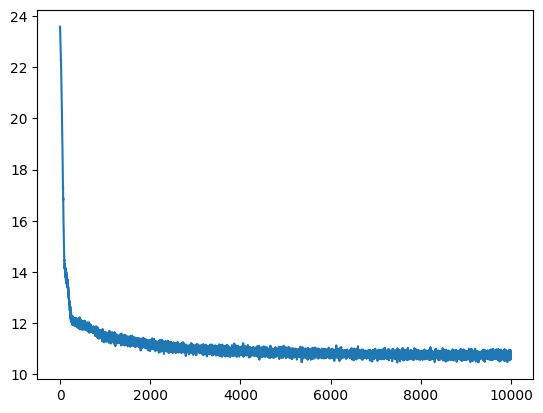

In [ ]:
plt.plot(l_expert)

16 4


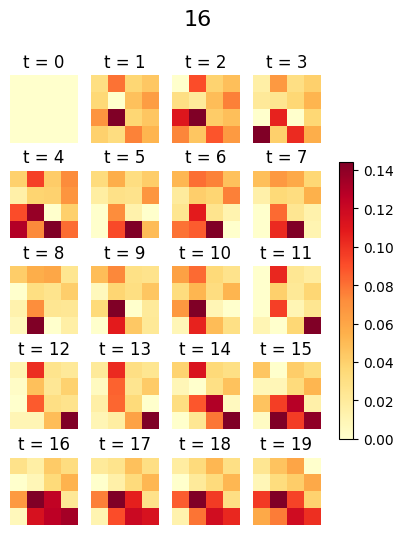

16 4


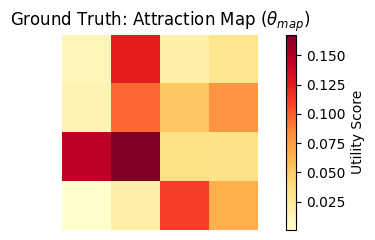

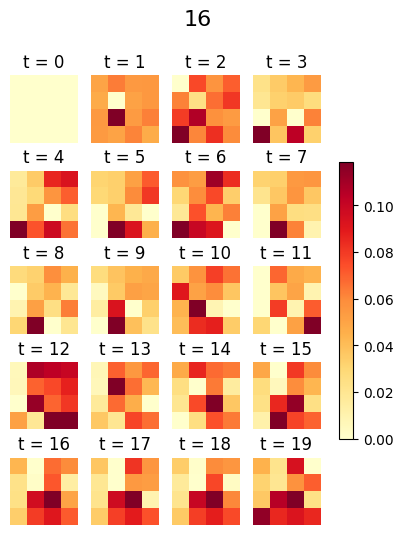

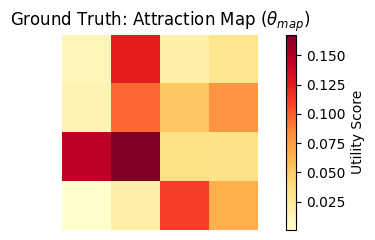

In [25]:
import matplotlib.pyplot as plt



# Visualize the path
rho = sample_rho(env_true,rho0, pi_expert, jax.random.PRNGKey(0), 1)
plot_city_evolution(rho.reshape(20, NB_STATES),env_true.theta_map, NB_STATES)

pi_bays_true = lambda t,x,rho: pi_expert_bays(t,x,rho, env_true.theta_map)
rho = sample_rho(env_true,rho0, pi_bays_true, jax.random.PRNGKey(0), 1)
plot_city_evolution(rho.reshape(20, NB_STATES),env_true.theta_map, NB_STATES)

In [ ]:
env_true.theta_cong

2

In [30]:
samples = sample_rho(env_true,rho0,pi_expert, jax.random.PRNGKey(12), 250)

In [31]:
samples.shape

(250, 320)

In [32]:
def compute_pdf_dir(theta, alpha):
    theta_map = theta
    p = jax.scipy.stats.dirichlet.pdf(theta_map, alpha*jnp.ones_like(theta_map))    
    return p

In [23]:
import jax
import jax.numpy as jnp
import optax
import equinox as eqx
from jax.scipy.special import logsumexp


# ──────────────────────────────────────────────────────────────────────────────
# 1.  LOG-POSTERIOR WITH A GAUSSIAN PRIOR
# ──────────────────────────────────────────────────────────────────────────────

def compute_log_posterior(
    theta,          # (theta_dim,)  – the point to evaluate
    samples,        # (N, H*nb_states) – observed rho trajectories
    model_flow,     # trained ConditionalMAF
    compute_pdf_theta,
):
    """
    Returns the *unnormalised* log-posterior (scalar):

        log p(theta | data)  ∝  log p(data | theta)  +  log p(theta)

    where:
        log p(data | theta)  = Σ_i  model_flow.log_prob(sample_i, theta)
        log p(theta)         = Σ_d  Normal(prior_mean[d], prior_std[d]).log_prob(theta[d])

    The evidence  log p(data)  is an additive constant we drop (unnormalised).

    Args:
        theta       : point in parameter space, shape (theta_dim,)
        samples     : N observed rho trajectories, shape (N, H*nb_states)
        model_flow  : trained ConditionalMAF with a .log_prob(rho_flat, theta) method
        prior_mean  : Gaussian prior mean, shape (theta_dim,)
        prior_std   : Gaussian prior std,  shape (theta_dim,)  (must be > 0)

    Returns:
        Scalar – unnormalised log-posterior at theta.
    """
    theta = jnp.atleast_1d(theta)

    # ── Log-likelihood: sum log p(rho_i | theta) over all N samples ──────────
    log_likelihoods = jax.vmap(lambda rho: model_flow.log_prob(rho, theta))(samples)
    log_lik = jnp.sum(log_likelihoods)          # scalar

    # ── Log-prior: isotropic (or diagonal) Gaussian ───────────────────────────
    # log N(theta; mu, sigma) = -0.5 * ((theta - mu) / sigma)^2
    #                           - log(sigma) - 0.5*log(2*pi)
    # The last two terms are constants and could be dropped, but we keep them
    # for correctness (matters when comparing posteriors across different priors).
    # log_prior = jnp.sum(
    #     -0.5 * ((theta - prior_mean) / prior_std) ** 2
    #     - jnp.log(prior_std)
    #     - 0.5 * jnp.log(2 * jnp.pi)
    # )
    p = compute_pdf_theta(theta)
    log_prior = jnp.log(p)

    return log_lik + log_prior


    opt_state = optimizer.init(theta_raw)

    # Negative log-posterior (what we minimise)
    def neg_log_post(theta_raw_):
        theta_ = constrain_fn(theta_raw_) if constrain_fn is not None else theta_raw_
        return -compute_log_posterior(theta_, samples, model_flow,compute_pdf_theta)

    @jax.jit
    def step(theta_raw_, opt_state_):
        loss, grads = jax.value_and_grad(neg_log_post)(theta_raw_)
        updates, new_opt_state = optimizer.update(grads, opt_state_)
        new_theta_raw = optax.apply_updates(theta_raw_, updates)
        return new_theta_raw, new_opt_state, loss

    loss_history = []
    for i in range(n_steps):
        theta_raw, opt_state, loss = step(theta_raw, opt_state)
        loss_history.append(float(loss))
        if verbose and (i % 500 == 0 or i == n_steps - 1):
            print(f"  step {i:>5d} | neg-log-posterior = {loss:.4f}")

    theta_map = constrain_fn(theta_raw) if constrain_fn is not None else theta_raw
    return theta_map, jnp.array(loss_history)

In [24]:
def find_map_gradient_descent(
    samples,
    model_flow,
    alpha_val, # Pass the scalar alpha directly
    n_steps=2000,
    lr=1e-3,
    verbose=True,
):
    theta_dim = model_flow.context_dim
    # Initialize z at zeros; Softmax(zeros) = Uniform distribution (1/N)
    z_init = jnp.ones(theta_dim)/theta_dim

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(z_init)

    def constrain_fn(z):
        return jax.nn.softmax(z)

    def neg_log_posterior(z_raw):
        theta = constrain_fn(z_raw)
        
        # 1. Likelihood (use MEAN to keep scale manageable)
        log_likelihoods = jax.vmap(lambda rho: model_flow.log_prob(rho, theta))(samples[:,NB_STATES:])
        log_lik = jnp.mean(log_likelihoods)

        # 2. Stable Log-Prior (Log-space only!)
        # Only the map part follows the Dirichlet
        log_prior_map = jax.scipy.stats.dirichlet.logpdf(
            theta, jnp.ones(NB_STATES) * alpha_val
        )
        
        # Total Log-Posterior
        return -(log_lik + log_prior_map)

    @jax.jit
    def step(z_raw, opt_state_):
        loss, grads = jax.value_and_grad(neg_log_posterior)(z_raw)
        updates, new_opt_state = optimizer.update(grads, opt_state_)
        new_z = optax.apply_updates(z_raw, updates)
        return new_z, new_opt_state, loss

    z_final = z_init
    losses = []
    for i in range(n_steps):
        z_final, opt_state, loss = step(z_final, opt_state)
        losses.append(loss)
        if verbose and i % 500 == 0:
            # Check if loss is nan to stop early
            if jnp.isnan(loss):
                print(f"Error: NaN encountered at step {i}")
                break
            print(f"Step {i} | Neg-Log-Post: {loss:.4f}")

    return constrain_fn(z_final), losses

In [ ]:
# Pass the scalar 0.3 directly as alpha_val
MAP, loss_map= find_map_gradient_descent(
    samples=samples,            
    model_flow=model_flow_city, 
    alpha_val=1,              # <--- Pass the number, not the lambda
    n_steps=5000,
    lr=1e-2,
    verbose=False
)

E0422 15:05:55.695058   88560 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.64 = f32[250,512]{0,1} fusion(split.63, constant.326), kind=kCustom, calls=gemm_fusion_dot.64_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0422 15:05:55.695154   88560 xtile_compiler.cc:401] Computation: gemm_fusion_dot.64_computation.clone {
  parameter_0.31 = f32[250,152]{1,0} parameter(0)
  parameter_1.31 = f32[152,512]{1,0} parameter(1)
  ROOT dot.111 = f32[250,512]{0,1} dot(parameter_0.31, parameter_1.31), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0422 15:05:55.888320   88565 xtile_compiler.c

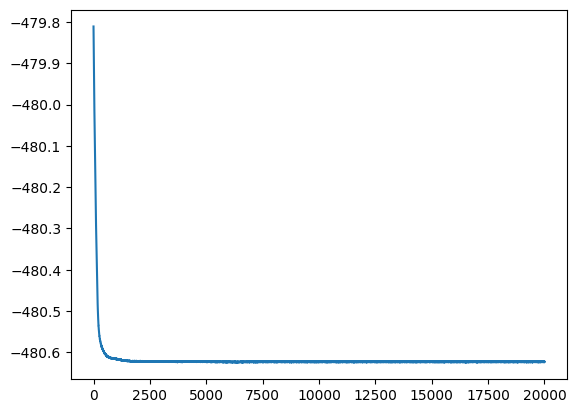

In [36]:
plt.plot(loss_map)

In [37]:
true_theta

Array([0.0007587 , 0.01820377, 0.1105096 , 0.06436664, 0.14660509,
       0.1678531 , 0.03451931, 0.03239869, 0.01286388, 0.09651351,
       0.05306546, 0.08011612, 0.00940856, 0.12499951, 0.01817633,
       0.02964171], dtype=float32)

In [38]:
MAP

Array([2.4259601e-08, 3.6134258e-02, 3.6690860e-08, 5.7036179e-01,
       2.6299432e-01, 2.5502521e-08, 1.2339572e-07, 2.0035875e-08,
       2.1777378e-08, 2.4098926e-08, 1.8224229e-08, 1.8177017e-08,
       2.4284507e-08, 1.3050918e-01, 4.0604409e-08, 3.1932831e-08],      dtype=float32)

In [39]:
jnp.sum(jnp.abs(true_theta - MAP))

Array(1.2916491, dtype=float32)

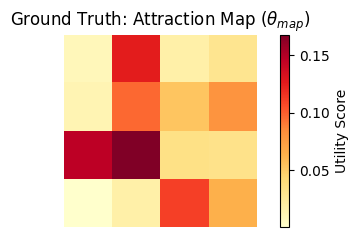

In [40]:
fig, axes = plt.subplots(1,figsize=(6, 2.5))
true_attraction = env_true.theta_map.reshape(4, 4)
im1 = axes.imshow(true_attraction, cmap='YlOrRd', origin='lower')
axes.set_title("Ground Truth: Attraction Map ($\\theta_{map}$)")
axes.axis('off')
plt.colorbar(im1, ax=axes, label="Utility Score")
# plt.tight_layout()
plt.show()

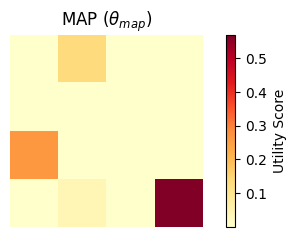

In [41]:
fig, axes = plt.subplots(1,figsize=(6, 2.5))
true_attraction = MAP.reshape(4, 4)
im1 = axes.imshow(true_attraction, cmap='YlOrRd', origin='lower')
axes.set_title("MAP ($\\theta_{map}$)")
axes.axis('off')
plt.colorbar(im1, ax=axes, label="Utility Score")
# plt.tight_layout()
plt.show()

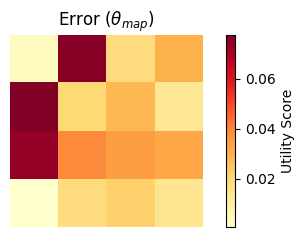

In [ ]:
fig, axes = plt.subplots(1,figsize=(6, 2.5))
true_attraction = jnp.abs(MAP - env_true.theta_map).reshape(4, 4)
im1 = axes.imshow(true_attraction, cmap='YlOrRd', origin='lower')
axes.set_title("Error ($\\theta_{map}$)")
axes.axis('off')
plt.colorbar(im1, ax=axes, label="Utility Score")
# plt.tight_layout()
plt.show()

In [ ]:
for N in [1, 10, 50, 100, 200]:
    samples = sample_rho(env_true, rho0, pi_bays_true, jax.random.PRNGKey(12), N)
    theta_est, _ = find_map_gradient_descent(
        samples, model_flow_city,
        alpha_val=1.0, 
        n_steps=3000, lr=1e-3, verbose=False
    )
    error = jnp.sum(jnp.abs(theta_est - env_true.theta_map))
    print(f"N={N:>4d} | L1 error: {error:.4f}")

N=   1 | L1 error: 1.0952


E0418 21:28:23.991300   37122 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[64,160]{1,0} fusion(get-tuple-element.37, bitcast.83), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["32","256"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0418 21:28:23.991508   37122 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0 = f32[64,33]{1,0} parameter(0)
  parameter_1 = f32[33,160]{0,1} parameter(1)
  ROOT dot.6 = f32[64,160]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["32"]}
}
E0418 21:28:24.005075   37115 xtile_compiler.cc:399] Fusio

N=  10 | L1 error: 0.4420
N=  50 | L1 error: 0.2654
N= 100 | L1 error: 0.3842


E0418 21:28:52.702652   37123 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.65 = f32[200,512]{0,1} fusion(add_any.55, constant.325), kind=kCustom, calls=gemm_fusion_dot.65_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0418 21:28:52.702844   37123 xtile_compiler.cc:401] Computation: gemm_fusion_dot.65_computation.clone {
  parameter_0.32 = f32[200,152]{1,0} parameter(0)
  constant_340 = f32[] constant(0.333333343)
  broadcast.154 = f32[200,152]{1,0} broadcast(constant_340), dimensions={}
  multiply.79 = f32[200,152]{1,0} multiply(parameter_0.32, broadcast.154)
  parameter_1.32 = f32[152,512]{1,0} parameter(1)
  ROOT d

N= 200 | L1 error: 0.4095


In [11]:
eqx.tree_serialise_leaves("pi_fic_bays.eqx", fictitious_ensemble_bays)

In [5]:
model_to_load  =  [BayesianPolicyCityCNN(env_true, key=jax.random.PRNGKey(0), film_hidden=64) for k in range(11)]
fictitious_ensemble_bays = eqx.tree_deserialise_leaves("pi_fic_bays.eqx", model_to_load)

In [13]:
import equinox as eqx

# Save the standard expert policy
# eqx.tree_serialise_leaves("pi_expert.eqx", pi_expert)

# Save the Bayesian expert policy
eqx.tree_serialise_leaves("pi_expert_bayes.eqx", pi_expert_bays)

In [8]:
# To load back later:
# 1. Create a fresh model with same params
model_to_load = BayesianPolicyNN(env_true, key=jax.random.PRNGKey(0), theta_dim=env_true.theta_dim, film_hidden=64)
# 2. Fill it with the saved weights
pi_expert_bays = eqx.tree_deserialise_leaves("pi_expert_bayes.eqx", model_to_load)

In [5]:
model_to_load  = PolicyNN(env_true, key=jax.random.PRNGKey(0))
pi_expert = eqx.tree_deserialise_leaves("pi_expert.eqx", model_to_load)

In [51]:
indices_I

Array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19], dtype=int32)

In [10]:


def train_nle_online(
    env, 
    model, 
    rho0,
    generate_theta,
    pi, 
    indices_I,        # [NEW] Time steps to include in training
    use_mu=False,     # [NEW] Toggle: True uses sample_theta_mu, False uses rho
    n_steps=10000,   
    lr=1e-4,         
    batch_size=128, 
    key=None
):
    if key is None: key = jax.random.PRNGKey(0)
    
    # 1. Setup Optimizer & Partition
    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(lr)
    )
    model_params, model_static = eqx.partition(model, eqx.is_array)
    opt_state = optimizer.init(model_params)

    theta_dim = env.theta_dim

    # --- The Core Step: Generate + Train ---
    def train_step(carry, step_key):
        params, opt_s = carry
        
        # 2. DATA GENERATION LOGIC
        if use_mu:
            # Uses the expected density simulation
            dataset = sample_theta_mu_bayesian(
                env, rho0, generate_theta, pi, step_key, batch_size
            )
            # 3. SLICE AND FILTER BY TIME STEPS
            thetas = dataset[:, :theta_dim]
            full_traj = dataset[:, theta_dim:] # (batch, H * nb_states)
            
            rho_flat = filter_samples(env, full_traj, indices_I, use_mu)
            dim_xi = env.nb_states*env.nb_actions
            rho_flat = apply_simplex_noise(key, rho_flat,dim_xi, strength=np.sqrt(dim_xi))
            # print(rho_flat.shape)
        else:
            # Uses the stochastic realization simulation
            dataset = sample_theta_rho_bayesian(
                env, rho0, generate_theta, pi, step_key, batch_size
            )
            # 3. SLICE AND FILTER BY TIME STEPS
            thetas = dataset[:, :theta_dim]
            full_traj = dataset[:, theta_dim:] # (batch, H * nb_states)
            
            rho_flat = filter_samples(env, full_traj, indices_I, use_mu)
            dim_xi = env.nb_states
            # print(rho_flat.shape)
            rho_flat = apply_simplex_noise(key, rho_flat,dim_xi, strength=np.sqrt(dim_xi))

        # 4. COMPUTE LOSS AND GRADIENT
        def loss_fn(p):
            m = eqx.combine(p, model_static)
            log_p = jax.vmap(m.log_prob)(rho_flat, thetas)

            # 1. Standard Negative Log Likelihood
            nll = -jnp.mean(log_p)
            # 2. LASSO / L1 Penalty (Encourages Sparsity)
            # We apply it to the conditioners to find the most important features
            # l1_sum = sum(jnp.sum(jnp.abs(l.weight)) for l in model.conditioners_l1)
            # 3. Combined Loss
            return nll 
            # return -jnp.mean(log_p)

        loss_val, grads = eqx.filter_value_and_grad(loss_fn)(params)
        
        # 5. UPDATE
        updates, next_opt_s = optimizer.update(grads, opt_s, params)
        next_params = eqx.apply_updates(params, updates)
        
        return (next_params, next_opt_s), loss_val

    # --- 6. Execution via lax.scan ---
    keys = jax.random.split(key, n_steps)
    
    (final_params, _), loss_history = jax.lax.scan(
        train_step, (model_params, opt_state), keys
    )
    
    return eqx.combine(final_params, model_static), loss_history    


In [11]:
indices_I = jnp.arange(H-1, 0, -1)[::-1]
model_flow_city = ConditionalMAF(
    event_dim      = len(indices_I) * NB_STATES,  # 304
    context_dim    = NB_STATES,             # 16
    hidden_dim     = 512,                   # 256 → 512
    num_layers     = 8,                     # 5 → 8
    nb_states      = NB_STATES,
    theta_embed_dim = 128,                  # 64 → 128 (context_dim doubled)
    key            = jax.random.PRNGKey(0),
    use_simplex=True
)

model_flow_city, loss_flow = train_nle_online(
    env_true, model_flow_city, rho0, generate_theta, pi_expert_bays,
    n_steps    = 25_000,
    indices_I=indices_I,
    lr         = 1e-3,
    batch_size = 256,
    key        = jax.random.PRNGKey(1), 
    use_mu=False
)

/tmp/ipykernel_6847/950212434.py:2: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  model_flow_city = ConditionalMAF(
E0423 11:34:12.650810    7127 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.13 = f32[256,512]{1,0} fusion(concatenate.72, get-tuple-element.469), kind=kCustom, calls=gemm_fusion_dot.13_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0423 11:34:12.650979    7127 xtile_compiler.cc:401] Computation: gemm_fusion_dot.13_computation.clone {
  parameter_0.9 = f32[256,736]{1,0} parameter(0)
  parameter_1.9 = f32[512,736]{1,0} parameter(1)

In [12]:
19*16

304

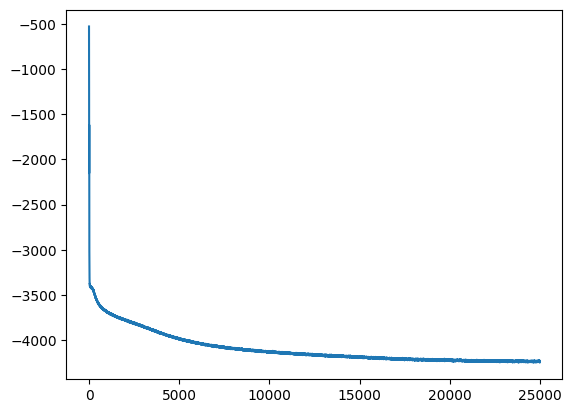

In [13]:
plt.plot(loss_flow)

In [14]:
r_uniform[0].reshape(H, NB_STATES)[0]

NameError: name 'r_uniform' is not defined

E0423 11:40:50.084344    7139 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[2,512,5]{2,1,0} fusion(bitcast.3, bitcast.2), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0423 11:40:50.084417    7139 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[512,2,368]{2,1,0} parameter(0)
  parameter_1 = f32[5,2,368]{2,1,0} parameter(1)
  ROOT dot = f32[2,512,5]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={1}, lhs_contracting_dims={2}, rhs_batch_dims={1}, rhs_contracting_dims={2}, backend_config={"sizes":[

Max diff between trajectories: 0.56851447
64 8


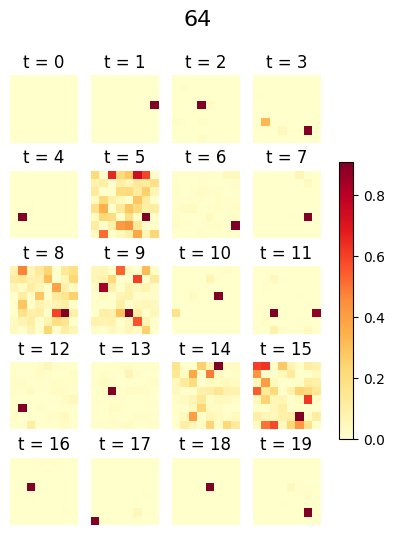

64 8


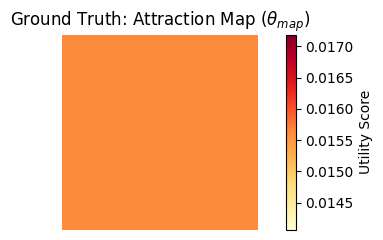

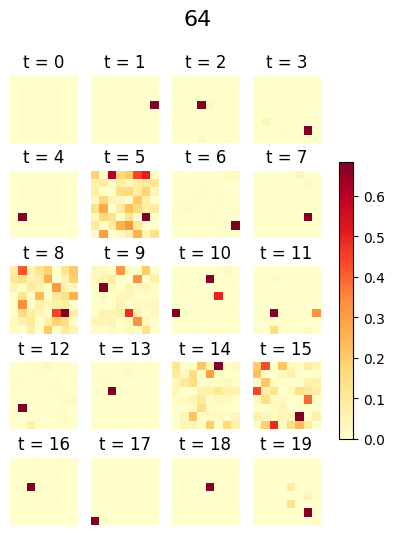

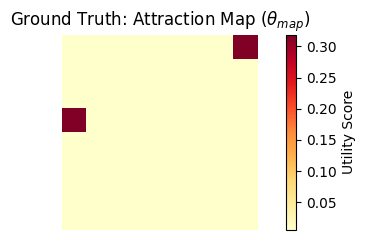

In [15]:
key = jax.random.PRNGKey(99)

peaked_arr = jnp.ones(NB_STATES)
peaked_arr = peaked_arr.at[-1].set(5)
peaked_arr = peaked_arr.at[NB_STATES//2].set(5)
theta_peaked  = jax.nn.softmax(peaked_arr)
theta_uniform = jnp.ones(NB_STATES) / NB_STATES

# Sample from each
r_uniform = model_flow_city.sample(theta_uniform, rho0, key, num_samples=5)
r_peaked  = model_flow_city.sample(theta_peaked,  rho0, key, num_samples=5)

print("Max diff between trajectories:", jnp.max(jnp.abs(r_peaked - r_uniform)))
# They should look DIFFERENT if the flow has learned the conditioning
plot_city_evolution(r_uniform[0].reshape(H, NB_STATES), theta_uniform, NB_STATES)
plot_city_evolution(r_peaked[0].reshape(H, NB_STATES),  theta_peaked, NB_STATES)

64 8


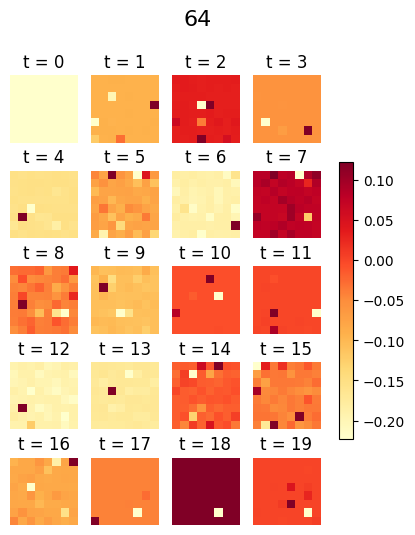

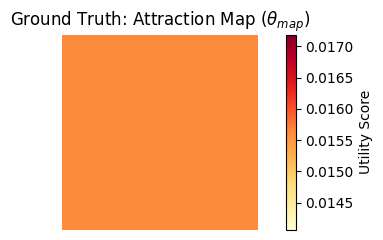

In [16]:
plot_city_evolution(r_peaked[0].reshape(H, NB_STATES) - r_uniform[0].reshape(H, NB_STATES) , theta_uniform, NB_STATES)

In [17]:
key_theta = jr.PRNGKey(20)#40
theta = generate_theta(key_theta, 1)[0]

In [18]:
pi_b_ = lambda t, x, r: pi_expert_bays(t, x, r, theta)

In [19]:
samples = sample_rho(env_true,rho0,pi_b_, jax.random.PRNGKey(12), 200)

E0423 11:43:10.731561    7134 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[64,12800]{1,0} fusion(get-tuple-element.37, bitcast.83), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0423 11:43:10.731733    7134 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0 = f32[64,129]{1,0} parameter(0)
  parameter_1 = f32[129,12800]{0,1} parameter(1)
  ROOT dot.6 = f32[64,12800]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}


In [25]:
# Pass the scalar 0.3 directly as alpha_val
MAP, loss_map= find_map_gradient_descent(
    samples=samples,            
    model_flow=model_flow_city, 
    alpha_val=1,              # <--- Pass the number, not the lambda
    n_steps=2000,
    lr=1e-2,
    verbose=False
)

E0423 11:44:02.409199    7127 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.64 = f32[200,512]{0,1} fusion(split.63, constant.326), kind=kCustom, calls=gemm_fusion_dot.64_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0423 11:44:02.409315    7127 xtile_compiler.cc:401] Computation: gemm_fusion_dot.64_computation.clone {
  parameter_0.31 = f32[200,608]{1,0} parameter(0)
  parameter_1.31 = f32[608,512]{1,0} parameter(1)
  ROOT dot.111 = f32[200,512]{0,1} dot(parameter_0.31, parameter_1.31), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0423 11:44:02.565339    7142 xtile_compiler.cc

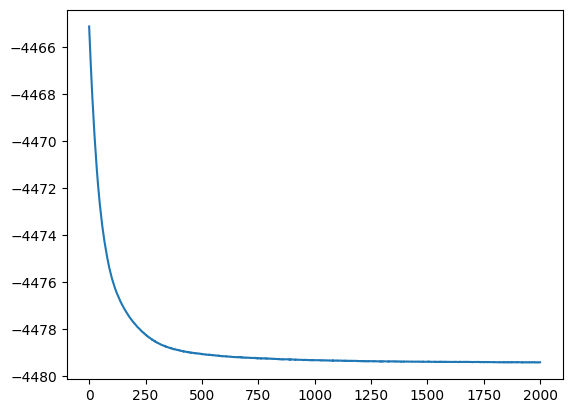

In [26]:
plt.plot(loss_map)

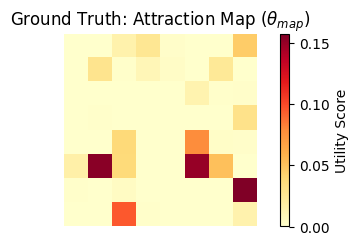

In [27]:
fig, axes = plt.subplots(1,figsize=(6, 2.5))
# true_attraction = env_true.theta_map.reshape(8, 8)
true_attraction = theta.reshape(8, 8)
im1 = axes.imshow(true_attraction, cmap='YlOrRd', origin='lower')
axes.set_title("Ground Truth: Attraction Map ($\\theta_{map}$)")
axes.axis('off')
plt.colorbar(im1, ax=axes, label="Utility Score")
# plt.tight_layout()
plt.show()

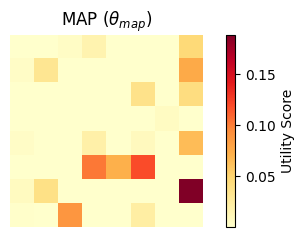

In [28]:
fig, axes = plt.subplots(1,figsize=(6, 2.5))
true_attraction = MAP.reshape(8, 8)
im1 = axes.imshow(true_attraction, cmap='YlOrRd', origin='lower')
axes.set_title("MAP ($\\theta_{map}$)")
axes.axis('off')
plt.colorbar(im1, ax=axes, label="Utility Score")
# plt.tight_layout()
plt.show()

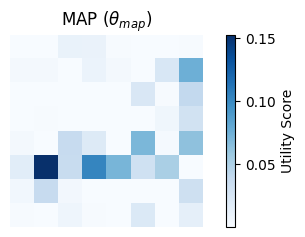

In [31]:
fig, axes = plt.subplots(1,figsize=(6, 2.5))
true_attraction = jnp.abs(MAP.reshape(8, 8) - theta.reshape(8, 8))
im1 = axes.imshow(true_attraction, cmap='Blues', origin='lower')
axes.set_title("MAP ($\\theta_{map}$)")
axes.axis('off')
plt.colorbar(im1, ax=axes, label="Utility Score")
# plt.tight_layout()
plt.show()

In [32]:
jnp.sum(jnp.abs(MAP - theta))

Array(1.0245107, dtype=float32)

In [37]:
jnp.sum(jnp.abs(theta - jax.random.dirichlet(jax.random.PRNGKey(np.random.randint(100)), alpha=jnp.ones(NB_STATES)*(1/NB_STATES))))

Array(1.9060133, dtype=float32)

In [191]:
100*np.sum(jnp.abs(MAP - true_theta))/jnp.sum(jnp.abs(true_theta - jax.random.normal(jax.random.PRNGKey(np.random.randint(100)), shape = true_theta.shape)))

Array(3.9923291, dtype=float32)